In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

import torch
import torch.nn as nn
import torch.nn.functional as F

In [ ]:
columns = ['engine_id', 'cycle', 'setting1', 'setting2', 'setting3'] + \
          [f'sensor{i}' for i in range(1, 22)]

In [ ]:
train_path = "project/data/train_FD001.txt"

train = pd.read_csv(
    train_path,
    sep=r"\s+",
    header=None
)
train.columns = columns

In [ ]:
engine_life = train.groupby('engine_id')['cycle'].max()

In [ ]:
setting_cols = ['setting1', 'setting2', 'setting3']
sensor_cols = [f'sensor{i}' for i in range(1, 22)]

In [ ]:
sensor_variance = train[sensor_cols].var().sort_values()
print(sensor_variance)

sensor19    0.000000e+00
sensor18    0.000000e+00
sensor16    2.422479e-28
sensor10    2.172333e-25
sensor5     1.152399e-23
sensor1     4.273435e-21
sensor6     1.929279e-06
sensor15    1.406628e-03
sensor8     5.038938e-03
sensor13    5.172330e-03
sensor21    1.171825e-02
sensor20    3.266927e-02
sensor11    7.133568e-02
sensor2     2.500533e-01
sensor12    5.439850e-01
sensor7     7.833883e-01
sensor17    2.398667e+00
sensor3     3.759099e+01
sensor4     8.101089e+01
sensor14    3.639005e+02
sensor9     4.876536e+02
dtype: float64


In [ ]:
drop_sensors = ['sensor1', 'sensor5', 'sensor6', 'sensor10', 'sensor16', 'sensor18', 'sensor19']
selected_sensors = [s for s in sensor_cols if s not in drop_sensors]
data = train[['engine_id', 'cycle'] + selected_sensors].copy()

In [ ]:
scaler = MinMaxScaler()

data[selected_sensors] = scaler.fit_transform(data[selected_sensors])


In [ ]:
healthy_parts = []

for engine_id in data['engine_id'].unique():
    engine_df = data[data['engine_id'] == engine_id].copy()
    max_cycle = engine_df['cycle'].max()

    healthy_df = engine_df[engine_df['cycle'] <= 0.5 * max_cycle]
    healthy_parts.append(healthy_df)

healthy_data = pd.concat(healthy_parts, ignore_index=True)

print("Original data shape:", data.shape)
print("Healthy data shape:", healthy_data.shape)

Original data shape: (20631, 16)
Healthy data shape: (10290, 16)


In [ ]:
def create_windows(df, sensor_cols, window_size):
    windows = []

    for engine_id in df['engine_id'].unique():
        engine_df = df[df['engine_id'] == engine_id]
        sensor_array = engine_df[sensor_cols].values

        for i in range(len(sensor_array) - window_size + 1):
            window = sensor_array[i:i + window_size]
            windows.append(window)

    return np.array(windows)

In [ ]:
engines = healthy_data['engine_id'].unique()

np.random.seed(42)
np.random.shuffle(engines)

split_idx = int(len(engines) * 0.8)

train_engines = engines[:split_idx]
val_engines = engines[split_idx:]

train_df = healthy_data[healthy_data['engine_id'].isin(train_engines)].copy()
val_df = healthy_data[healthy_data['engine_id'].isin(val_engines)].copy()

print("Number of train engines:", len(train_engines))
print("Number of val engines:", len(val_engines))
print("Train df shape:", train_df.shape)
print("Val df shape:", val_df.shape)

Number of train engines: 80
Number of val engines: 20
Train df shape: (8152, 16)
Val df shape: (2138, 16)


In [ ]:
window_size = 30

X_train = create_windows(train_df, selected_sensors, window_size)
X_val = create_windows(val_df, selected_sensors, window_size)

No need to flatten the training data anymore.

In [ ]:
class LSTMAutoencoder(nn.Module):
    def __init__(self, input_size, hidden_size, latent_size):
        super().__init__()

        self.input_size = input_size
        self.hidden_size = hidden_size
        self.latent_size = latent_size

        self.encoder = nn.LSTM(input_size=input_size,hidden_size=hidden_size,batch_first=True)
        self.to_latent = nn.Linear(hidden_size, latent_size)

        self.latent_to_hidden = nn.Linear(latent_size, hidden_size)
        self.latent_to_cell = nn.Linear(latent_size, hidden_size)

        self.decoder = nn.LSTM(input_size=input_size,hidden_size=hidden_size,batch_first=True)
        self.output_layer = nn.Linear(hidden_size, input_size)

    def forward(self, x):
      batch_size, seq_len, _ = x.size()

      _, (hn, cn) = self.encoder(x)
      latent = self.to_latent(hn[-1])

      h0_dec = self.latent_to_hidden(latent).unsqueeze(0)
      c0_dec = self.latent_to_cell(latent).unsqueeze(0)

      decoder_input = torch.zeros_like(x)
      decoder_input[:, 1:, :] = x[:, :-1, :]

      decoded, _ = self.decoder(decoder_input, (h0_dec, c0_dec))
      reconstructed = self.output_layer(decoded)

      return reconstructed

In [ ]:
model = LSTMAutoencoder(input_size=14, hidden_size=64, latent_size=16)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [ ]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)

In [ ]:
from torch.utils.data import DataLoader, TensorDataset

batch_size = 64

train_dataset = TensorDataset(X_train_tensor, X_train_tensor)
val_dataset = TensorDataset(X_val_tensor, X_val_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

In [ ]:
num_epochs = 10

train_losses = []
val_losses = []

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0

    for batch_x, _ in train_loader:
        optimizer.zero_grad()

        outputs = model(batch_x)
        loss = criterion(outputs, batch_x)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * batch_x.size(0)

    train_loss /= len(train_loader.dataset)
    train_losses.append(train_loss)

    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for batch_x, _ in val_loader:
            outputs = model(batch_x)
            loss = criterion(outputs, batch_x)
            val_loss += loss.item() * batch_x.size(0)

    val_loss /= len(val_loader.dataset)
    val_losses.append(val_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}")

Epoch [1/10], Train Loss: 0.033454, Val Loss: 0.007061
Epoch [2/10], Train Loss: 0.005488, Val Loss: 0.004740
Epoch [3/10], Train Loss: 0.004689, Val Loss: 0.004656
Epoch [4/10], Train Loss: 0.004661, Val Loss: 0.004637
Epoch [5/10], Train Loss: 0.004646, Val Loss: 0.004602
Epoch [6/10], Train Loss: 0.004640, Val Loss: 0.004619
Epoch [7/10], Train Loss: 0.004630, Val Loss: 0.004577
Epoch [8/10], Train Loss: 0.004614, Val Loss: 0.004568
Epoch [9/10], Train Loss: 0.004604, Val Loss: 0.004599
Epoch [10/10], Train Loss: 0.004592, Val Loss: 0.004556


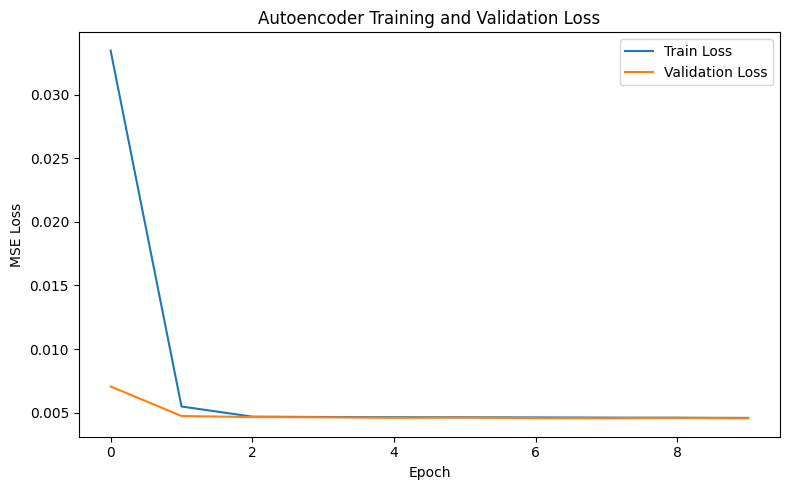

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Autoencoder Training and Validation Loss')
plt.legend()
plt.tight_layout()
plt.savefig("project/figures/autoencoder_loss_curve_pytorch.png", dpi=300)
plt.show()

In [ ]:
model.eval()

with torch.no_grad():
    reconstructed = model(X_train_tensor)
    train_errors = torch.mean((X_train_tensor - reconstructed) ** 2, dim=(1, 2))

print(train_errors[:10])
print("Mean train reconstruction error:", train_errors.mean().item())

tensor([0.0047, 0.0046, 0.0047, 0.0047, 0.0046, 0.0047, 0.0047, 0.0047, 0.0048,
        0.0048])
Mean train reconstruction error: 0.004586328752338886


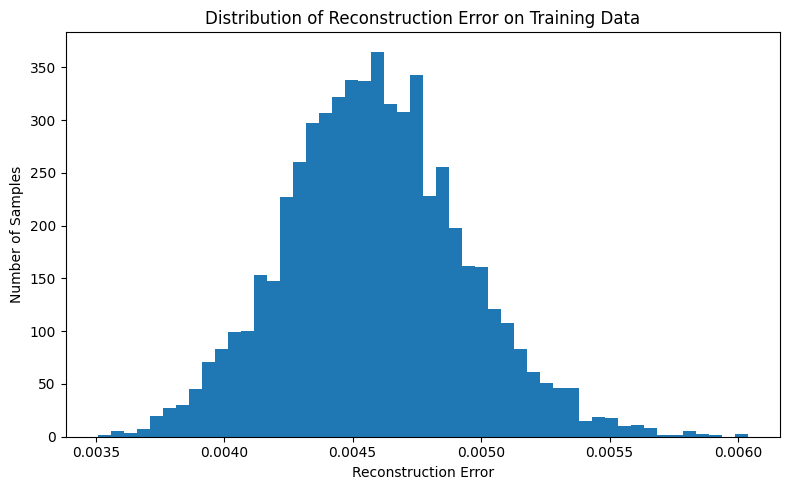

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(train_errors.numpy(), bins=50)
plt.xlabel("Reconstruction Error")
plt.ylabel("Number of Samples")
plt.title("Distribution of Reconstruction Error on Training Data")
plt.tight_layout()
plt.show()

In [ ]:
test_path = "project/data/test_FD001.txt"

test = pd.read_csv(
    test_path,
    sep=r'\s+',
    header=None
)

test.columns = columns
test.head()

test = test[selected_sensors + ['engine_id', 'cycle']]
test[selected_sensors] = scaler.transform(test[selected_sensors])

X_test = create_windows(test, selected_sensors, window_size)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

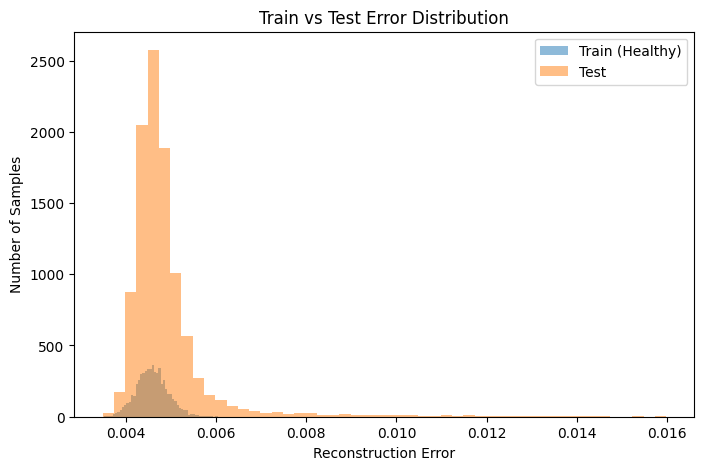

In [ ]:
with torch.no_grad():
    reconstructed_test = model(X_test_tensor)
    test_errors = torch.mean((X_test_tensor - reconstructed_test) ** 2, dim=(1, 2))


plt.figure(figsize=(8,5))
plt.hist(train_errors.numpy(), bins=50, alpha=0.5, label='Train (Healthy)')
plt.hist(test_errors.numpy(), bins=50, alpha=0.5, label='Test')
plt.legend()


plt.xlabel("Reconstruction Error")
plt.ylabel("Number of Samples")
plt.title("Train vs Test Error Distribution")
plt.show()

Threshold (95th percentile of healthy train error): 0.005185

Summary:
status
detected        52
not_detected    45
too_short        3
Name: count, dtype: int64

First 20 results:
    engine_id  num_windows  degradation_start_window  \
0           1            2                       NaN   
1           2           20                       NaN   
2           3           97                       NaN   
3           4           77                       NaN   
4           5           69                       NaN   
5           6           76                       NaN   
6           7          131                       1.0   
7           8          137                       NaN   
8           9           26                       NaN   
9          10          163                       NaN   
10         11           54                      16.0   
11         12          188                      20.0   
12         13          166                       NaN   
13         14           17          

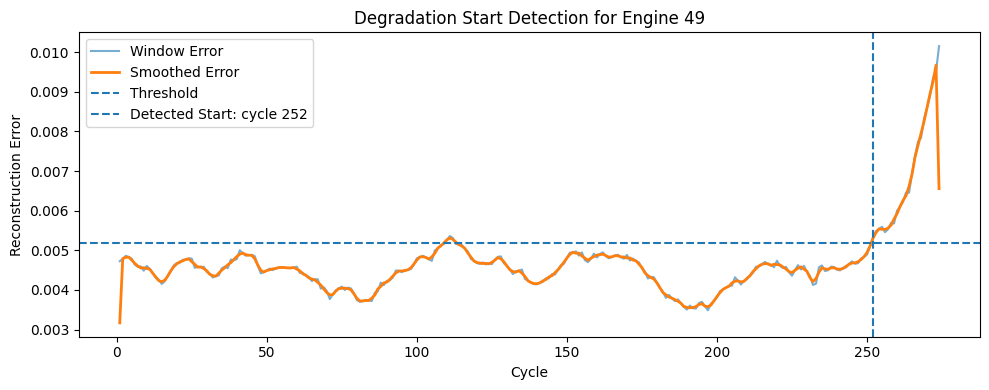


Saved results to degradation_start_results_relaxed.csv


In [ ]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

# =========================
# helper functions
# =========================
def create_windows_with_meta(df, sensor_cols, window_size):
    windows = []
    meta = []

    for engine_id in sorted(df['engine_id'].unique()):
        engine_df = df[df['engine_id'] == engine_id].sort_values('cycle').reset_index(drop=True)
        sensor_array = engine_df[sensor_cols].values
        cycle_array = engine_df['cycle'].values

        for i in range(len(sensor_array) - window_size + 1):
            windows.append(sensor_array[i:i + window_size])
            meta.append({
                'engine_id': int(engine_id),
                'start_cycle': int(cycle_array[i]),
                'end_cycle': int(cycle_array[i + window_size - 1]),
                'window_index_within_engine': i
            })

    return np.array(windows), pd.DataFrame(meta)

def moving_average(x, w=3):
    if len(x) < w:
        return x.copy()
    return np.convolve(x, np.ones(w) / w, mode='same')

def find_degradation_start(errors, threshold, consecutive=5):
    count = 0
    for i, e in enumerate(errors):
        if e > threshold:
            count += 1
            if count >= consecutive:
                return i - consecutive + 1
        else:
            count = 0
    return None

# =========================
# 1) threshold: relax from 99% -> 95%
# =========================
train_errors_np = train_errors.detach().cpu().numpy()
threshold = np.percentile(train_errors_np, 95)
print(f"Threshold (95th percentile of healthy train error): {threshold:.6f}")

# =========================
# 2) ordered test windows
# =========================
X_test_ordered, test_meta = create_windows_with_meta(test, selected_sensors, window_size)
X_test_ordered_tensor = torch.tensor(X_test_ordered, dtype=torch.float32)

# =========================
# 3) reconstruction errors
# use same full-window mean MSE as train_errors
# =========================
model.eval()
with torch.no_grad():
    recon_test_ordered = model(X_test_ordered_tensor)
    test_window_errors = ((X_test_ordered_tensor - recon_test_ordered) ** 2).mean(dim=(1, 2)).cpu().numpy()

test_meta['reconstruction_error'] = test_window_errors

# =========================
# 4) detect per-engine onset
# skip engines with too few windows
# =========================
results = []

for engine_id in sorted(test_meta['engine_id'].unique()):
    engine_meta = test_meta[test_meta['engine_id'] == engine_id].copy().reset_index(drop=True)
    engine_errors = engine_meta['reconstruction_error'].values
    num_windows = len(engine_errors)

    # too short -> unreliable onset detection
    if num_windows < 10:
        results.append({
            'engine_id': int(engine_id),
            'num_windows': num_windows,
            'degradation_start_window': None,
            'degradation_start_cycle_est': None,
            'status': 'too_short'
        })
        continue

    smoothed = moving_average(engine_errors, w=3)
    start_idx = find_degradation_start(smoothed, threshold, consecutive=5)

    if start_idx is not None:
        start_cycle = int(engine_meta.loc[start_idx, 'start_cycle'])
        status = 'detected'
    else:
        start_cycle = None
        status = 'not_detected'

    results.append({
        'engine_id': int(engine_id),
        'num_windows': num_windows,
        'degradation_start_window': start_idx,
        'degradation_start_cycle_est': start_cycle,
        'status': status
    })

results_df = pd.DataFrame(results)

print("\nSummary:")
print(results_df['status'].value_counts())
print("\nFirst 20 results:")
print(results_df.head(20))

# =========================
# 5) choose a long engine automatically for plotting
# =========================
candidate_df = results_df[(results_df['num_windows'] >= 30)].copy()

if len(candidate_df) == 0:
    print("\nNo engine has enough windows for a meaningful onset plot.")
else:
    # prefer one with detected onset; otherwise just choose the longest one
    detected_candidates = candidate_df[candidate_df['status'] == 'detected']

    if len(detected_candidates) > 0:
        engine_to_plot = int(detected_candidates.sort_values('num_windows', ascending=False).iloc[0]['engine_id'])
    else:
        engine_to_plot = int(candidate_df.sort_values('num_windows', ascending=False).iloc[0]['engine_id'])

    engine_meta = test_meta[test_meta['engine_id'] == engine_to_plot].copy().reset_index(drop=True)
    engine_errors = engine_meta['reconstruction_error'].values
    smoothed = moving_average(engine_errors, w=3)
    start_idx = find_degradation_start(smoothed, threshold, consecutive=5)

    plt.figure(figsize=(10, 4))
    plt.plot(engine_meta['start_cycle'], engine_errors, label='Window Error', alpha=0.6)
    plt.plot(engine_meta['start_cycle'], smoothed, label='Smoothed Error', linewidth=2)
    plt.axhline(threshold, linestyle='--', label='Threshold')

    if start_idx is not None:
        detected_cycle = int(engine_meta.loc[start_idx, 'start_cycle'])
        plt.axvline(detected_cycle, linestyle='--', label=f'Detected Start: cycle {detected_cycle}')
        print(f"\nEngine {engine_to_plot}: degradation start detected around cycle {detected_cycle}")
    else:
        print(f"\nEngine {engine_to_plot}: no degradation onset detected, but plotted because it has enough windows")

    plt.xlabel("Cycle")
    plt.ylabel("Reconstruction Error")
    plt.title(f"Degradation Start Detection for Engine {engine_to_plot}")
    plt.legend()
    plt.tight_layout()
    plt.show()

# =========================
# 6) save
# =========================
results_df.to_csv("degradation_start_results_relaxed.csv", index=False)
print("\nSaved results to degradation_start_results_relaxed.csv")